1. LINEAR REGRESSION

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv('sports_training_dataset.csv')
features = [
    'age', 'height_cm', 'weight_kg', 'resting_heart_rate', 'max_heart_rate',
    'VO2_max', 'cumulative_hits', 'cumulative_runs', 'training_hours_per_week',
    'reaction_time_sec', 'agility_score', 'strength_score', 'endurance_score',
    'training_load_au', 'speed_index', 'fatigue_score', 'recovery_time_hr',
    'biomechanical_efficiency', 'participation_ratio_pct', 'long_term_training_effect_pct',
    'adaptation_pct', 'training_session_count', 'fitness_score', 'feedback_score'
]
X = data[features]
y = data['training_effectiveness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Optimized Model Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")
importance = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=False)
display(importance.head(10))

Optimized Model Results:
Mean Squared Error: 0.0000
R-squared Score: 1.0000


,Feature,Coefficient
6,cumulative_hits,3.994172
12,endurance_score,2.887267
10,agility_score,2.853577
11,strength_score,2.818615
7,cumulative_runs,2.758509
8,training_hours_per_week,2.561351
14,speed_index,1.475311
13,training_load_au,1.380214
20,adaptation_pct,1.288751
18,participation_ratio_pct,0.872330


2. MULTI LINEAR REGRESSION

--- Multi-Linear Regression Results ---
R-squared Score: 1.0000
Mean Squared Error: 0.0000


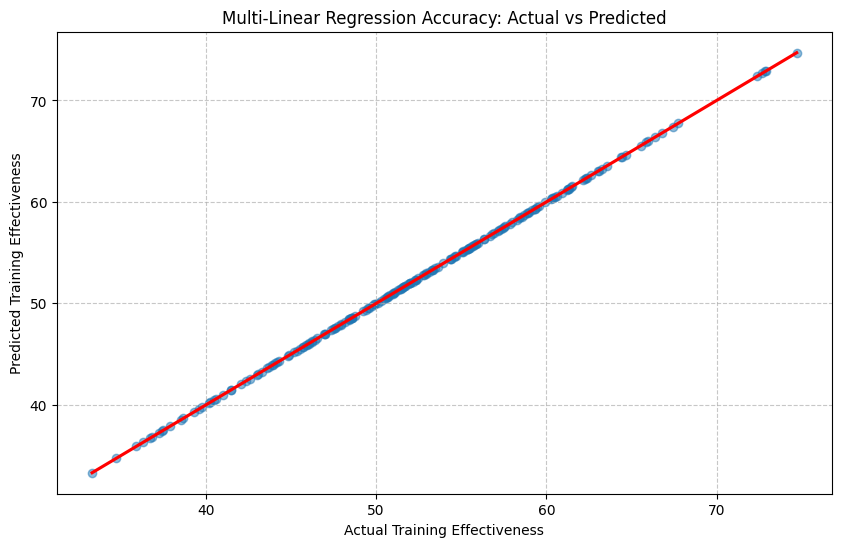

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv('sports_training_dataset.csv')
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in numerical_cols:
    numerical_cols.remove('training_effectiveness')
X = data[numerical_cols]
y = data['training_effectiveness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"--- Multi-Linear Regression Results ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Actual Training Effectiveness')
plt.ylabel('Predicted Training Effectiveness')
plt.title('Multi-Linear Regression Accuracy: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()